In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

In [3]:
PROJECT_ROOT = Path.cwd().parent

TRAIN_DIR = PROJECT_ROOT / "data" / "raw" / "train"
TEST_DIR = PROJECT_ROOT / "data" / "raw" / "test"

### Image Parameters

In [12]:
IMG_HEIGHT = 48
IMG_WIDTH = 48

BATCH_SIZE = 32
SEED = 42
VALIDATION_SPLIT = 0.2

INPUT_SHAPE = (
    IMG_HEIGHT,
    IMG_WIDTH
)

### A- Tensorflow dataset

#### I - Creating Training Dataset

In [13]:
# Load data 
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory = TRAIN_DIR,
    validation_split = VALIDATION_SPLIT,
    labels = 'inferred',
    label_mode='int',
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=INPUT_SHAPE,
    shuffle=True,
    seed=SEED,
    subset="training",
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.


#### II - Creating Validation dataset

In [14]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    directory = TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    labels = 'inferred',
    label_mode = 'int',
    color_mode = "grayscale",
    batch_size = BATCH_SIZE,
    image_size = INPUT_SHAPE,
    shuffle= True,
    seed = SEED,
    subset= 'validation'
)

Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [29]:
# one batch
images,labels = next(iter(train_ds))
labels

<tf.Tensor: shape=(32,), dtype=int32, numpy=
array([6, 1, 4, 2, 6, 5, 2, 5, 0, 5, 3, 6, 3, 0, 2, 4, 3, 6, 5, 2, 4, 4,
       3, 6, 3, 4, 4, 4, 3, 3, 2, 4], dtype=int32)>

In [30]:
class_names = train_ds.class_names

for i, class_name in enumerate(class_names):
    print(f"{i} -> {class_name}")

0 -> angry
1 -> disgust
2 -> fear
3 -> happy
4 -> neutral
5 -> sad
6 -> surprise


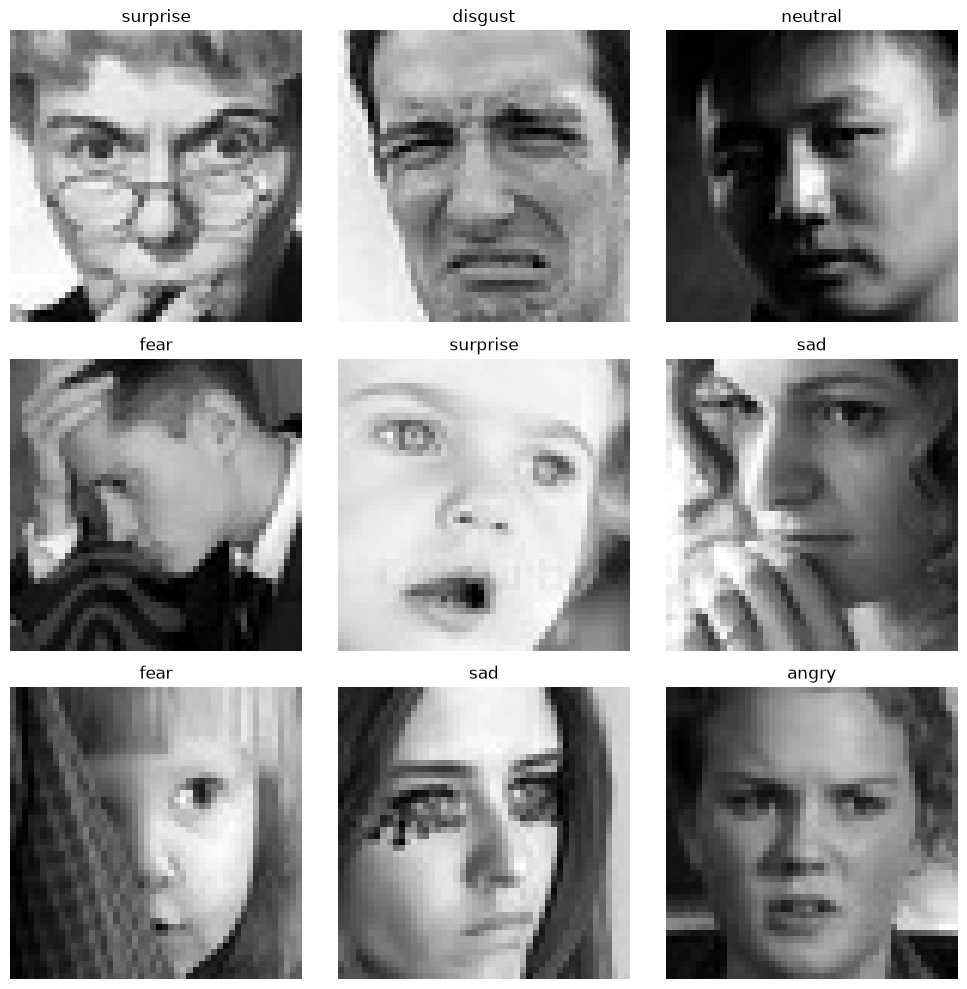

In [31]:
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().squeeze(), cmap="gray")
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

### B- Handling Class Imbalance

####  Get All Training Labels

In [32]:
train_labels = []

for _, labels in train_ds:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)

In [37]:
# Class Distribution

unique, counts = np.unique(train_labels, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{train_ds.class_names[label]:10s} : {count}")

angry      : 3218
disgust    : 363
fear       : 3285
happy      : 5813
neutral    : 3965
sad        : 3834
surprise   : 2490


#### I - By Assigning Class Weights

In [38]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

In [39]:
class_weight_dict = {
    i: weight
    for i, weight in enumerate(class_weights)
}

print(class_weight_dict)

{0: np.float64(1.0196217703986505), 1: np.float64(9.03896103896104), 2: np.float64(0.998825831702544), 3: np.float64(0.5644491410877098), 4: np.float64(0.8275265717888669), 5: np.float64(0.8558014755197854), 6: np.float64(1.3177280550774526)}


#### II - By Augmenting Data

In [40]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomZoom(0.1),
        layers.RandomRotation(0.1),
        layers.RandomContrast(0.1)
    ], name = "data_augmentaion"
)

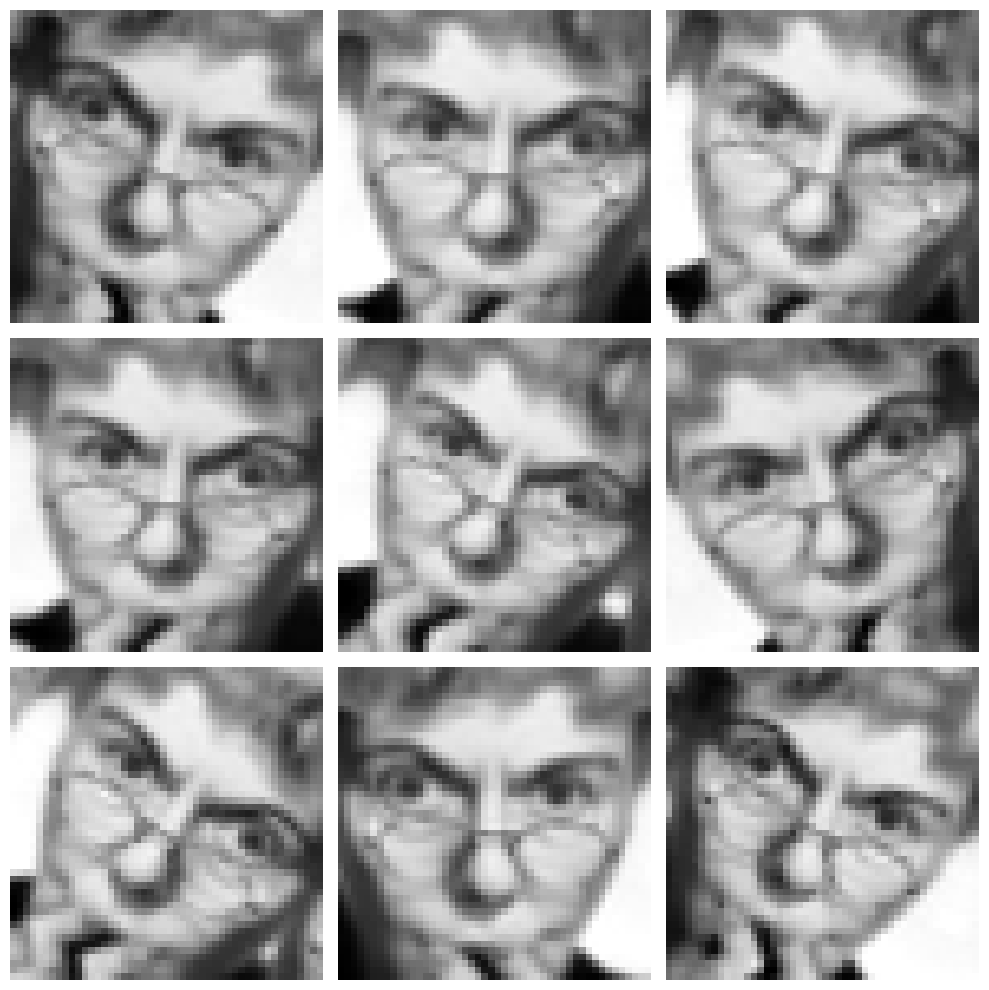

In [41]:
sample_image = images[0]

plt.figure(figsize=(10, 10))

for i in range(9):
    augmented = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )

    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

### C - Normalization & Pipeline Optimization

In [42]:
normalization = layers.Rescaling(1./255)

In [43]:
# before nomalization
sample_image = images[0]
print(sample_image.numpy().min())
print(sample_image.numpy().max())

1.0
255.0


In [44]:
normalized_image = normalization(sample_image)

print(normalized_image.numpy().min())
print(normalized_image.numpy().max())

0.003921569
1.0


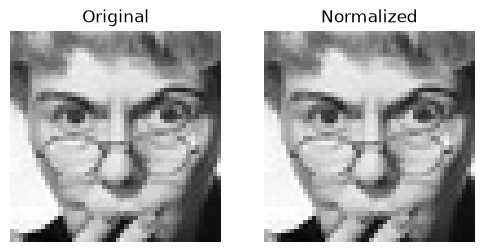

In [47]:
# Visulalize 

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(sample_image.numpy().squeeze(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(normalized_image.numpy().squeeze(), cmap="gray")
plt.title("Normalized")
plt.axis("off")

plt.show()